In [1]:
# Import all needed libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Read 1 of the 9 files to see what it looks like 
# Start from the most important data, which is the GDP Growth
desktop  = os.path.join(os.path.expanduser("~"), "Desktop")
filepath = os.path.join(desktop, "API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_260.csv")

df_gdp = pd.read_csv(filepath, skiprows = 4)

# Check how many rows and columns it contains
print("Shape:", df_gdp.shape)

Shape: (266, 71)


In [3]:
# Look at the first 5 rows to understand the structure of the data
df_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,3.493430,3.212471,1.225112,-23.897990,14.730616,10.636431,7.706798,6.810777,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,0.418937,7.937038,5.623764,4.649241,5.138168,...,2.677524,2.705194,2.030077,-2.817572,4.578772,3.722717,1.931160,2.763839,NaN,NaN
2,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.266944,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,1.869593,3.726090,7.038388,5.364089,4.105339,...,2.296349,2.904664,3.281683,-3.730630,2.549691,4.472795,3.662428,4.585674,NaN,NaN
4,Angola,AGO,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.149396,-0.594411,-0.204680,-4.042447,2.102753,4.216003,1.263308,4.423907,NaN,NaN


In [4]:
# See all column names
print(df_gdp.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [5]:
# Keep the country columns and year columns only
year_cols = [str(y) for y in range(1960, 2026)]

df_gdp = df_gdp[["Country Name", "Country Code"] + year_cols]

# Rename country name and code
df_gdp = df_gdp.rename(columns = {"Country Name": "country", "Country Code": "country_code"})

In [6]:
# Check the data set after making such changes
print("Structure of the data:", df_gdp.shape)
print(df_gdp.head(5))

Structure of the data: (266, 68)
                       country country_code  1960      1961      1962  \
0                        Aruba          ABW   NaN       NaN       NaN   
1  Africa Eastern and Southern          AFE   NaN  0.418937  7.937038   
2                  Afghanistan          AFG   NaN       NaN       NaN   
3   Africa Western and Central          AFW   NaN  1.869593  3.726090   
4                       Angola          AGO   NaN       NaN       NaN   

       1963      1964      1965      1966      1967  ...      2016      2017  \
0       NaN       NaN       NaN       NaN       NaN  ...  1.234335  3.493430   
1  5.623764  4.649241  5.138168  4.827421  5.338839  ...  2.130117  2.677524   
2       NaN       NaN       NaN       NaN       NaN  ...  2.260314  2.647003   
3  7.038388  5.364089  4.105339 -1.513011 -8.966703  ...  0.194316  2.296349   
4       NaN       NaN       NaN       NaN       NaN  ... -1.700530 -0.149396   

       2018      2019       2020       2021    

In [7]:
# Change the format of the data
df_gdp = df_gdp.melt(id_vars = ["country_code", "country"], var_name = "year", value_name = "gdp_growth")

# Convert year to an integer because this helps us to filter the values more conveniently
df_gdp["year"] = df_gdp["year"].astype(int)
df_gdp["gdp_growth"] = pd.to_numeric(df_gdp["gdp_growth"], errors = "coerce")

print("Number of rows and columns of the data set:", df_gdp.shape)
print(df_gdp.head(3))

Number of rows and columns of the data set: (17556, 4)
  country_code                      country  year  gdp_growth
0          ABW                        Aruba  1960         NaN
1          AFE  Africa Eastern and Southern  1960         NaN
2          AFG                  Afghanistan  1960         NaN


In [8]:
# Check year range
print("Year range:", df_gdp["year"].min(), "to", df_gdp["year"].max())

Year range: 1960 to 2025


In [9]:
# Load all 8 files
all_files = [("API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_260.csv", "gdp_growth"), ("API_NE.TRD.GNFS.ZS_DS2_en_csv_v2_101.csv", "trade"),
    ("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv", "inflation"), ("API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_698.csv", "investment"),
    ("API_SE.SEC.ENRR_DS2_en_csv_v2_758.csv", "school_enrolment"), ("API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv", "unemployment"),("API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_13.csv", "fdi"),
    ("API_FM.LBL.BMNY.GD.ZS_DS2_en_csv_v2_5797.csv", "broad_money")]

In [10]:
dfs = []

for filename, varname in all_files:
    filepath = os.path.join(desktop, filename)
    df_temp = pd.read_csv(filepath, skiprows = 4)
    
    df_temp = df_temp[["Country Name", "Country Code"] + year_cols]
    df_temp = df_temp.rename(columns = {"Country Name": "country", "Country Code": "country_code"})
    
    df_temp = df_temp.melt(id_vars = ["country_code", "country"], var_name = "year", value_name = varname)
    
    df_temp["year"] = df_temp["year"].astype(int)
    df_temp[varname] = pd.to_numeric(df_temp[varname], errors="coerce")

    dfs.append(df_temp)

In [11]:
# Start with the first dataframe as the base
df = dfs[0].copy()

# Merge each remaining dataframe one by one
for df_next in dfs[1:]:
    df = pd.merge(df, df_next.drop(columns=["country"]), on = ["country_code", "year"], how = "outer")

print("Number of rows and columns:", df.shape)
print(df.head(3))

Number of rows and columns: (17556, 11)
  country_code country  year  gdp_growth  trade  inflation  investment  \
0          ABW   Aruba  1960         NaN    NaN        NaN         NaN   
1          ABW   Aruba  1961         NaN    NaN        NaN         NaN   
2          ABW   Aruba  1962         NaN    NaN        NaN         NaN   

   school_enrolment  unemployment  fdi  broad_money  
0               NaN           NaN  NaN          NaN  
1               NaN           NaN  NaN          NaN  
2               NaN           NaN  NaN          NaN  


In [12]:
# Check the year range for all variable
print("gdp_growth year range:", df["year"].min(), "to", df["year"].max())
print("trade year range:", df["year"].min(), "to", df["year"].max())
print("inflation year range:", df["year"].min(), "to", df["year"].max())
print("investment year range:", df["year"].min(), "to", df["year"].max())
print("school_enrolment year range:", df["year"].min(), "to", df["year"].max())
print("unemployment year range:", df["year"].min(), "to", df["year"].max())
print("fdi year range:", df["year"].min(), "to", df["year"].max())
print("broad_money year range:", df["year"].min(), "to", df["year"].max())

gdp_growth year range: 1960 to 2025
trade year range: 1960 to 2025
inflation year range: 1960 to 2025
investment year range: 1960 to 2025
school_enrolment year range: 1960 to 2025
unemployment year range: 1960 to 2025
fdi year range: 1960 to 2025
broad_money year range: 1960 to 2025


In [13]:
# Save the merged file to Desktop so we can open it in Excel
out_path = os.path.join(desktop, "pre_cleaned_data.csv")

df.to_csv(out_path, index = False)

In [23]:
# Check the structure of the data after merging all variables into one data frame. 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_code      17556 non-null  object 
 1   country           17556 non-null  object 
 2   year              17556 non-null  int64  
 3   gdp_growth        14133 non-null  float64
 4   trade             10929 non-null  float64
 5   inflation         9066 non-null   float64
 6   investment        10647 non-null  float64
 7   school_enrolment  8362 non-null   float64
 8   unemployment      8211 non-null   float64
 9   fdi               11800 non-null  float64
 10  broad_money       10881 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 1.5+ MB
None


In [27]:
# Check if there are any duplicate data
duplicates = df.duplicated(subset = ["country_code", "year"])

print("Duplicate rows:", duplicates.sum())

Duplicate rows: 0


In [29]:
# Drop the rows with missing values
df_clean = df.dropna() 

# Check how many rows we have before and after
print("Rows before dropping missing:", df.shape)
print("Rows after dropping missing:", df_clean.shape)

Rows before dropping missing: (17556, 11)
Rows after dropping missing: (2571, 11)


In [33]:
# Keep only rows where the year is between 2000 and 2024 because not all the countries contain data between 1960 and 2024. Therefore, we need to narrow down the time frame.
df_clean = df_clean.query("year >= 2000 and year <= 2024")

# Check the result
print("Year range:", df_clean["year"].min(), "to", df_clean["year"].max())
print("Shape:", df_clean.shape)
print("First 3 rows:")
print(df_clean.head(3))

Year range: 2000 to 2024
Shape: (2184, 11)
First 3 rows:
    country_code                      country  year  gdp_growth      trade  \
106          AFE  Africa Eastern and Southern  2000    3.181375  46.557169   
107          AFE  Africa Eastern and Southern  2001    3.503533  47.955964   
108          AFE  Africa Eastern and Southern  2002    3.917113  57.294304   

     inflation  investment  school_enrolment  unemployment       fdi  \
106   8.601485   18.983457         27.737129      7.668768  1.534056   
107   5.840354   18.234958         28.789110      7.553885  4.774770   
108   8.763755   17.647979         29.475451      7.511493  2.453114   

     broad_money  
106    35.852469  
107    39.613793  
108    41.111370  


In [35]:
# AFE (Africa Eastern and Southern) is a regional code, not a real country. Therefore, we need to remove it from the data.
df_clean = df_clean.query("country_code != 'AFE'")

# Check the result
print("Countries remaining:", df_clean["country_code"].nunique())
print("Shape:", df_clean.shape)

Countries remaining: 139
Shape: (2159, 11)


In [37]:
# Save the final cleaned file to the Desktop
out_path = os.path.join(desktop, "cleaned_data.csv")

df_clean.to_csv(out_path, index = False)

In [39]:
# Read the cleaned data file in the desktop
desktop  = os.path.join(os.path.expanduser("~"), "Desktop")
filepath = os.path.join(desktop, "cleaned_data.csv")

df = pd.read_csv(filepath)

In [41]:
# Select the variables we want to use
corr_vars = ["gdp_growth", "trade", "inflation", "investment","school_enrolment", "unemployment", "fdi", "broad_money"]

In [43]:
# Rename all variables
corr_labels = {"gdp_growth": "GDP Growth (%)", "trade": "Trade (% GDP)", "inflation": "Inflation (%)", "investment": "Investment (% GDP)",
               "school_enrolment": "School Enrolment (%)", "unemployment": "Unemployment (%)", "fdi": "FDI (% GDP)", "broad_money": "Broad Money (% GDP)"}

In [45]:
# Compute the statistical summary 
summary = (df[corr_vars].rename(columns = corr_labels) .describe() .T .round(2))

In [47]:
# Rename each column and 
summary.columns = ["Count", "Mean", "Std Dev", "Min", "25%", "50%", "75%", "Max"]

In [49]:
# Display the output 1
print("Table 1: Statistical Summary for 139 countries between 2000 and 2024")
print(summary.to_string(justify = "center"))

Table 1: Statistical Summary for 139 countries between 2000 and 2024
                       Count  Mean   Std Dev   Min    25%    50%    75%      Max  
GDP Growth (%)        2159.0   3.85    4.89  -54.40   1.93   3.93   5.93     75.31
Trade (% GDP)         2159.0  81.60   46.25   15.28  53.06  72.95  97.73    442.62
Inflation (%)         2159.0   5.70    8.45  -16.86   1.81   3.71   7.11    133.49
Investment (% GDP)    2159.0  24.79    7.76    5.50  19.76  23.72  28.31     70.33
School Enrolment (%)  2159.0  79.08   27.60    6.23  62.96  86.32  98.09    159.11
Unemployment (%)      2159.0   7.39    5.91    0.10   3.43   5.56   9.94     37.32
FDI (% GDP)           2159.0   3.96    6.29  -40.11   1.19   2.71   4.89    105.64
Broad Money (% GDP)   2159.0  79.73  463.27    5.54  33.45  52.40  75.51  13083.81


In [51]:
# Calculate the average GDP growth across all countries
growth_by_year = (df.groupby("year")["gdp_growth"].mean().reset_index().round(2))

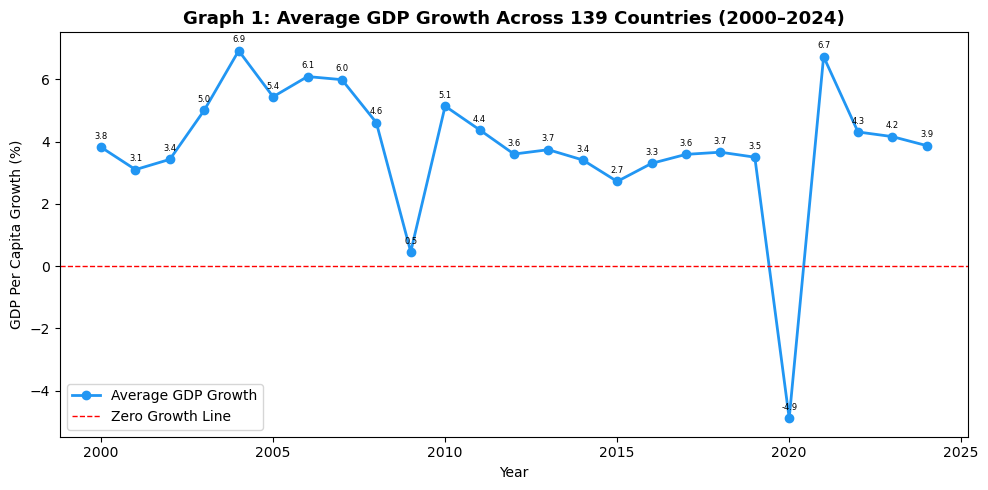

In [53]:
# Plot the output 2
plt.figure(figsize = (10, 5))

plt.plot(growth_by_year["year"], growth_by_year["gdp_growth"], marker = "o", linewidth = 2, color = "#2196F3", label = "Average GDP Growth")
plt.axhline(0, color = "red", linewidth = 1, linestyle = "--", label = "Zero Growth Line")
for x, y in zip(growth_by_year["year"], growth_by_year["gdp_growth"]):
    plt.text(x, y + 0.2, f"{y:.1f}", ha = "center", va = "bottom", fontsize = 6, color = "#000000")

plt.title("Graph 1: Average GDP Growth Across 139 Countries (2000–2024)", fontsize = 13, fontweight = "bold")
plt.xlabel("Year")
plt.ylabel("GDP Per Capita Growth (%)")
plt.legend()

plt.tight_layout() 
plt.show()

In [54]:
# Compute the correlation matrix
df_corr = (df[corr_vars].rename(columns = corr_labels).corr(numeric_only = True))

print("Correlation matrix:")
print(df_corr.round(2))

Correlation matrix:
                      GDP Growth (%)  Trade (% GDP)  Inflation (%)  \
GDP Growth (%)                  1.00           0.02           0.01   
Trade (% GDP)                   0.02           1.00          -0.12   
Inflation (%)                   0.01          -0.12           1.00   
Investment (% GDP)              0.13           0.11          -0.04   
School Enrolment (%)           -0.16           0.23          -0.09   
Unemployment (%)               -0.08          -0.05           0.05   
FDI (% GDP)                     0.08           0.48          -0.03   
Broad Money (% GDP)             0.04           0.03          -0.02   

                      Investment (% GDP)  School Enrolment (%)  \
GDP Growth (%)                      0.13                 -0.16   
Trade (% GDP)                       0.11                  0.23   
Inflation (%)                      -0.04                 -0.09   
Investment (% GDP)                  1.00                  0.05   
School Enrolment (%

In [55]:
# Compute the average Investment and FDI each year
output_5 = (df.groupby("year")[["investment", "fdi"]].mean().reset_index().round(2))

print("Average Investment and FDI by year:")
print(output_5)

Average Investment and FDI by year:
    year  investment   fdi
0   2000       21.62  2.81
1   2001       21.99  2.93
2   2002       22.60  3.11
3   2003       22.62  2.67
4   2004       22.73  3.33
5   2005       24.14  4.38
6   2006       25.14  5.38
7   2007       26.15  6.74
8   2008       27.92  5.72
9   2009       25.51  3.89
10  2010       25.82  4.06
11  2011       25.77  4.69
12  2012       26.07  4.68
13  2013       25.09  3.67
14  2014       25.47  3.73
15  2015       25.32  3.88
16  2016       24.88  4.18
17  2017       24.99  3.40
18  2018       25.47  2.97
19  2019       25.01  3.93
20  2020       23.91  3.59
21  2021       24.99  3.97
22  2022       26.08  4.17
23  2023       24.34  2.30
24  2024       23.00  3.04


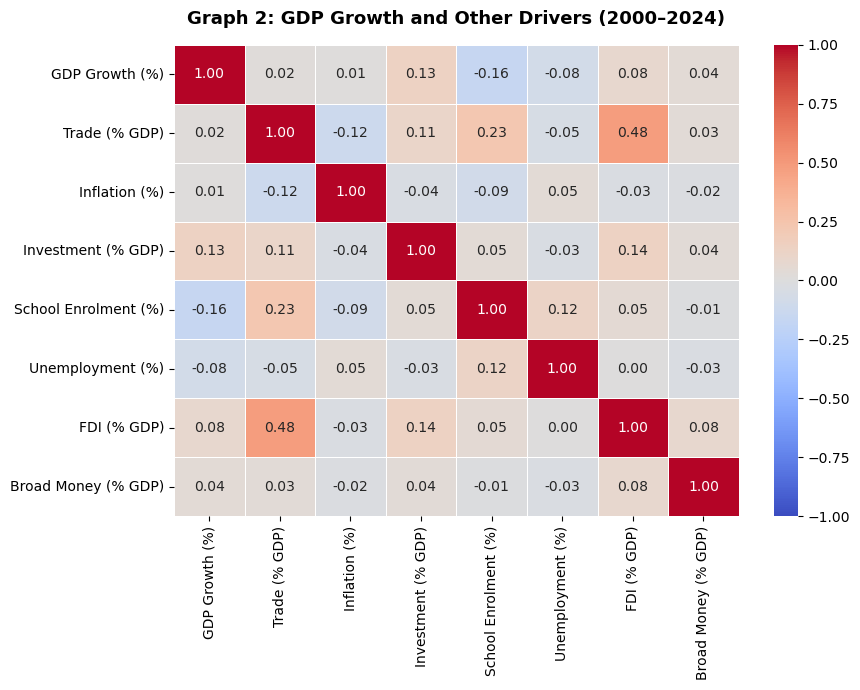

In [59]:
# Plot the correlation heatmap (Output 3)
plt.figure(figsize = (9, 7))

sns.heatmap(df_corr, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0,  vmin = - 1, vmax = 1, linewidths = 0.5)
plt.title("Graph 2: GDP Growth and Other Drivers (2000–2024)", fontsize = 13, fontweight = "bold", pad = 15)

plt.tight_layout() 
plt.show()

In [61]:
# Compute average Investment and FDI across all countries by year
drivers_by_year = (df.groupby("year")[["investment", "fdi"]].mean().reset_index().round(2))

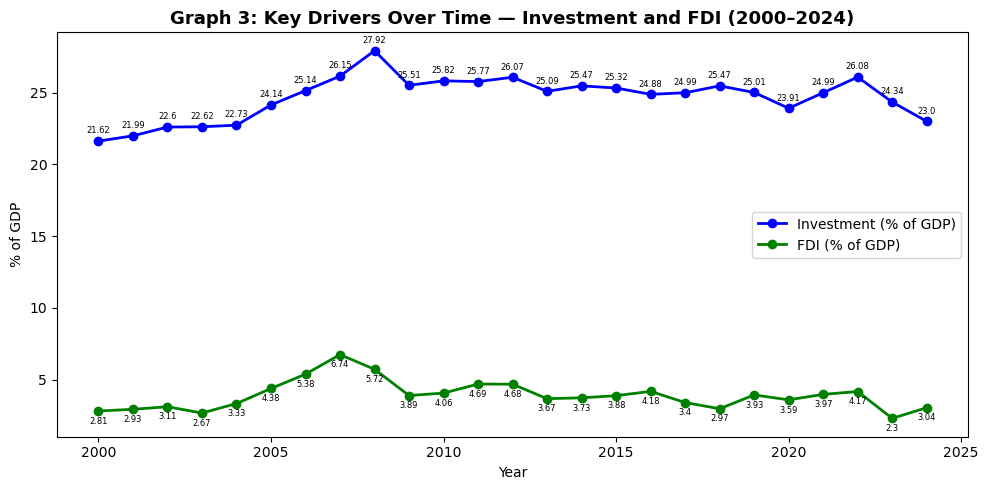

In [63]:
# Plot the overall trend of Investment and FDI over time (output 5)
plt.subplots(figsize = (10, 5))

plt.plot(drivers_by_year["year"], drivers_by_year["investment"], marker = "o", linewidth = 2, color = "#0000FF", label = "Investment (% of GDP)")
plt.plot(drivers_by_year["year"], drivers_by_year["fdi"], marker = "o", linewidth = 2, color = "#008000", label = "FDI (% of GDP)")
for x, inv, fdi in zip(drivers_by_year["year"], drivers_by_year["investment"], drivers_by_year["fdi"]):
    plt.text(x, inv + 0.4, f"{inv}", ha = 'center', va = 'bottom', fontsize = 6, color = "#000000")
    plt.text(x, fdi - 0.4, f"{fdi}", ha = 'center', va = 'top', fontsize = 6, color = "#000000")
    
plt.title("Graph 3: Key Drivers Over Time — Investment and FDI (2000–2024)", fontsize = 13, fontweight = "bold")
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.legend(loc = "center right")

plt.tight_layout() 
plt.show()

In [64]:
recent = df[df["year"] >= 2020]
country_avg = recent.groupby(["country_code", "country"])[["gdp_growth", "investment", "fdi"]].mean().round(2)

In [67]:
# Average per country for recent years
recent = df[df["year"] >= 2000]
country_avg = recent.groupby(["country_code", "country"])[["gdp_growth", "school_enrolment",]].mean().round(2)

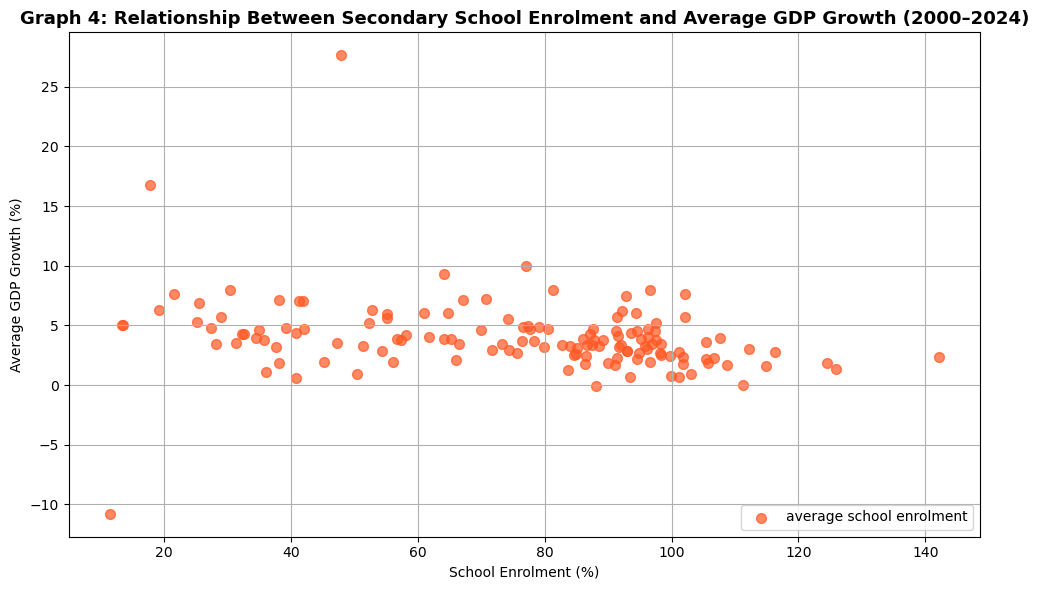

In [76]:
# Plot the School Enrolment vs GDP Growth graph (output 6)
plt.figure(figsize = (10, 6))
country_avg.plot(kind = "scatter", x = "school_enrolment", y = "gdp_growth", s = 50, alpha = 0.7, color = "#FF5722", label = "average school enrolment", 
ax = plt.gca())

plt.title("Graph 4: Relationship Between Secondary School Enrolment and Average GDP Growth (2000–2024)", fontsize = 13, fontweight ="bold")
plt.xlabel("School Enrolment (%)")
plt.ylabel("Average GDP Growth (%)")
plt.grid(True)
plt.legend(loc = "lower right")

plt.tight_layout() 
plt.show()

In [71]:
# Calculate the average of investment and fdi ecah countries between 2000 and 2024
output_6 = df[df["year"] >= 2000]
country_avg = output_6.groupby(["country_code", "country"])[["gdp_growth", "investment", "fdi", "school_enrolment"]].mean().round(2)

In [73]:
# Use GDP growth to find the top 10 and bottom 10 countries (output 6)
top10  = country_avg.sort_values("gdp_growth", ascending = False).head(10)
bottom10 = country_avg.sort_values("gdp_growth", ascending = False).tail(10)

print("Table 2: Top 10 Countries in Average GDP Growth beyween 2000–2024")
print(top10.to_string(justify = "center"))

print("\nTable 3: Bottom 10 Countries in Average GDP Growth between 2000–2024")
print(bottom10.to_string(justify = "center"))

Table 2: Top 10 Countries in Average GDP Growth beyween 2000–2024
                                gdp_growth  investment   fdi  school_enrolment
country_code country                                                          
IRQ          Iraq                  27.64       13.13    0.96        47.86     
GNQ          Equatorial Guinea     16.75       39.48    9.36        17.76     
CHN          China                 10.01       40.88    3.57        76.99     
ZWE          Zimbabwe               9.33        9.53    2.00        64.14     
TJK          Tajikistan             7.98       19.34    5.06        81.30     
RWA          Rwanda                 7.96       20.51    2.11        30.50     
QAT          Qatar                  7.93       36.64    1.89        96.55     
UGA          Uganda                 7.61       21.11    5.19        21.61     
LBY          Libya                  7.61       15.86    1.72       102.16     
MAC          Macao SAR, China       7.46       19.54    7.32     